# Routing

In [1]:
import osmnx as ox
import networkx as nx
from shapely.geometry import LineString, Point
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
import math
import os
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd

# ==========================================

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

if os.path.exists("manhattan.graphml"):
    G = ox.load_graphml("manhattan.graphml")
else:
    G = ox.graph_from_place("Manhattan, New York, USA", network_type="drive")
    ox.save_graphml(G, "manhattan.graphml")

# ==========================================


class Stop:
    def __init__(self, request_id, lat, lon, is_pickup):
        """
        request_id: int or string. IMPORTANT: Pickup and Dropoff for the same
                    passenger must share the same request_id.
        lat, lon: coordinates
        is_pickup: bool (True for pickup, False for dropoff)
        """
        self.request_id = request_id
        self.lat = lat
        self.lon = lon
        self.is_pickup = is_pickup

    def __repr__(self):
        type_str = "PICKUP" if self.is_pickup else "DROPOFF"
        return f"<Stop {self.request_id}: {type_str}>"


# ==========================================


class Route:
    def __init__(self, G, stops, vehicle_start_coords, start_time, speed_mph):
        """
        G: The OSMnx graph (Lat/Lon)
        stops: List of Stop objects (Pickups and Dropoffs)
        vehicle_start_coords: Tuple (lat, lon) of the car's initial position
        start_time: datetime object
        speed_mph: float
        """
        self.G_latlon = G
        self.all_stops = stops
        self.start_coords = vehicle_start_coords
        self.start_time = start_time
        self.speed_mps = speed_mph * 0.44704

        # State variables
        self.optimal_sequence = []  # List of Stop objects in order
        self.stop_arrival_times = []  # List of arrival datetimes for each stop
        self.route_line = None  # Shapely LineString of the full path
        self.total_distance = 0  # Meters
        self.G_proj = None  # Projected graph (meters)
        self.route_nodes = []  # List of Node IDs for the full path

        # Project graph immediately to enable Manhattan calc in meters
        self.G_proj = ox.project_graph(G)

    def _solve_tsp_gurobi(self):
        """
        Uses Gurobi to find optimal visit order using Manhattan Distance.
        Constraints:
        1. Precedence (Pickup before Dropoff)
        2. Capacity <= 4
        3. Open TSP (Fixed Start, Open End - Do NOT return to start)
        """
        # 1. Prepare Nodes: [Start_Node] + [Stop_Objects...]
        # We create a temporary list where index 0 is vehicle start
        node_list = [
            {
                "lat": self.start_coords[0],
                "lon": self.start_coords[1],
                "type": "start",
                "id": "start",
            }
        ]

        # Map request_id to indices for precedence constraints
        req_to_pickup_idx = {}
        req_to_dropoff_idx = {}

        for i, stop in enumerate(self.all_stops):
            idx = i + 1  # Offset by 1 because 0 is start
            node_list.append({"lat": stop.lat, "lon": stop.lon, "obj": stop})

            if stop.is_pickup:
                req_to_pickup_idx[stop.request_id] = idx
            else:
                req_to_dropoff_idx[stop.request_id] = idx

        n = len(node_list)
        capacity = 4

        # 2. Project all points to obtain X/Y in meters for Manhattan Calc
        # We use the graph's CRS transformer
        import pyproj

        transformer = pyproj.Transformer.from_crs(
            self.G_latlon.graph["crs"], self.G_proj.graph["crs"], always_xy=True
        )

        coords_xy = []
        for node in node_list:
            x, y = transformer.transform(node["lon"], node["lat"])
            coords_xy.append((x, y))

        # 3. Calculate Cost Matrix (Manhattan Distance)
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    # Manhattan: |x1 - x2| + |y1 - y2|
                    dist[i, j] = abs(coords_xy[i][0] - coords_xy[j][0]) + abs(
                        coords_xy[i][1] - coords_xy[j][1]
                    )

        # 4. Gurobi Model
        m = gp.Model("Rideshare_TSP")
        m.setParam("OutputFlag", 0)

        # Variables
        x = m.addVars(n, n, vtype=GRB.BINARY, name="x")  # Edge selection
        u = m.addVars(n, vtype=GRB.CONTINUOUS, name="u")  # Visit order
        l = m.addVars(
            n, vtype=GRB.CONTINUOUS, lb=0, ub=capacity, name="load"
        )  # Capacity

        # Objective: Minimize Total Distance
        m.setObjective(
            gp.quicksum(dist[i, j] * x[i, j] for i in range(n) for j in range(n)),
            GRB.MINIMIZE,
        )

        # --- Open TSP Flow Constraints ---
        # 1. Start Node (0): Leaves exactly once. Enters 0 times.
        m.addConstr(gp.quicksum(x[0, j] for j in range(1, n)) == 1, name="Start_Leave")
        m.addConstr(gp.quicksum(x[i, 0] for i in range(n)) == 0, name="Start_Enter")

        # 2. Stop Nodes (1..N): Must be entered exactly once.
        for j in range(1, n):
            m.addConstr(
                gp.quicksum(x[i, j] for i in range(n) if i != j) == 1, name=f"Enter_{j}"
            )

        # 3. Stop Nodes (1..N): Leave at most once (The last node leaves 0 times).
        for i in range(1, n):
            m.addConstr(
                gp.quicksum(x[i, j] for j in range(1, n) if i != j) <= 1,
                name=f"Leave_{i}",
            )

        # 4. Total Edges: Must equal n-1 (Linear path visiting n nodes)
        m.addConstr(
            gp.quicksum(x[i, j] for i in range(n) for j in range(n)) == n - 1,
            name="Total_Edges",
        )

        # --- Subtour Elimination & Timing ---
        # u[i] represents the order in sequence.
        for i in range(n):
            for j in range(n):
                if i != j:
                    m.addConstr(u[i] - u[j] + n * x[i, j] <= n - 1)

        # --- Precedence Constraints (Pickup time < Dropoff time) ---
        for req_id, p_idx in req_to_pickup_idx.items():
            if req_id in req_to_dropoff_idx:
                d_idx = req_to_dropoff_idx[req_id]
                m.addConstr(u[p_idx] <= u[d_idx] - 1)

        # --- Capacity Logic ---
        # Load at start is 0
        m.addConstr(l[0] == 0)

        for i in range(n):
            for j in range(1, n):
                if i != j:
                    # Determine change
                    change = 0
                    if j in req_to_pickup_idx.values():
                        change = 1
                    if j in req_to_dropoff_idx.values():
                        change = -1

                    # If x[i,j]=1 -> l[j] = l[i] + change
                    M = capacity + 5
                    m.addConstr(l[j] >= l[i] + change - M * (1 - x[i, j]))
                    m.addConstr(l[j] <= l[i] + change + M * (1 - x[i, j]))

        m.optimize()

        if m.status == GRB.OPTIMAL:
            # Extract Sequence (Follow the path from 0)
            seq_indices = [0]
            curr = 0
            while True:
                found_next = False
                for j in range(n):
                    if curr != j and x[curr, j].X > 0.5:
                        seq_indices.append(j)
                        curr = j
                        found_next = True
                        break
                if not found_next:
                    # Reached the end of the path (node with no outgoing edges)
                    break

            # Convert indices back to Stop Objects
            # seq_indices[0] is vehicle start, so we skip it
            self.optimal_sequence = [node_list[i]["obj"] for i in seq_indices if i != 0]
            return True
        else:
            print("Infeasible or Failed to solve.")
            return False

    def generate_route(self):
        # 1. Solve Optimal Order
        success = self._solve_tsp_gurobi()
        if not success:
            return False

        # 2. Construct Full Path (Segment by Segment)
        full_route_points = []
        self.route_nodes = []
        self.stop_arrival_times = []  # Reset arrival times

        # Tracking variables for time calculation
        current_cumulative_dist = 0

        # Complete sequence: Start_Coords -> Stop1 -> Stop2 ... -> StopN
        # We create a temporary list of coordinate tuples for routing
        routing_sequence = [self.start_coords] + [
            (s.lat, s.lon) for s in self.optimal_sequence
        ]

        print(f"Generating route for {len(routing_sequence)} points...")

        for i in range(len(routing_sequence) - 1):
            start_pt = routing_sequence[i]
            end_pt = routing_sequence[i + 1]

            # Find nearest nodes on Projected Graph
            # Lat/Lon -> Project -> Nearest Node

            import pyproj

            transformer = pyproj.Transformer.from_crs(
                self.G_latlon.graph["crs"], self.G_proj.graph["crs"], always_xy=True
            )

            # Start
            sx, sy = transformer.transform(start_pt[1], start_pt[0])
            orig_node = ox.nearest_nodes(self.G_proj, X=sx, Y=sy)

            # End
            ex, ey = transformer.transform(end_pt[1], end_pt[0])
            dest_node = ox.nearest_nodes(self.G_proj, X=ex, Y=ey)

            try:
                # Calculate path for this segment
                segment_nodes = nx.shortest_path(
                    self.G_proj, orig_node, dest_node, weight="length"
                )

                # Append nodes
                if i > 0:
                    self.route_nodes.extend(segment_nodes[1:])
                else:
                    self.route_nodes.extend(segment_nodes)

                # Extract geometry points (x, y)
                segment_points = [
                    (self.G_proj.nodes[n]["x"], self.G_proj.nodes[n]["y"])
                    for n in segment_nodes
                ]

                # -- Calculate distance and time for this specific segment --
                if len(segment_points) >= 2:
                    seg_len = LineString(segment_points).length
                else:
                    seg_len = 0

                current_cumulative_dist += seg_len

                # Calculate arrival time at the END of this segment (which is Stop i+1)
                arrival_time = self.start_time + timedelta(
                    seconds=current_cumulative_dist / self.speed_mps
                )
                self.stop_arrival_times.append(arrival_time)
                # -----------------------------------------------------------

                if i > 0:
                    full_route_points.extend(segment_points[1:])
                else:
                    full_route_points.extend(segment_points)

            except nx.NetworkXNoPath:
                print(f"Warning: No path found between sequence index {i} and {i + 1}")
                # If path fails, we assume 0 distance/time addition to avoid index misalignment,
                # though the time will be inaccurate.
                self.stop_arrival_times.append(
                    self.stop_arrival_times[-1]
                    if self.stop_arrival_times
                    else self.start_time
                )

        # 3. Create LineString
        if len(full_route_points) < 2:
            full_route_points.append(full_route_points[0])

        self.route_line = LineString(full_route_points)
        self.total_distance = self.route_line.length
        return True

    def get_location_at_time(self, query_time):
        if not self.route_line:
            return self.start_coords

        time_elapsed = (query_time - self.start_time).total_seconds()
        if time_elapsed <= 0:
            return self.start_coords

        dist_traveled = time_elapsed * self.speed_mps

        # If finished trip
        if dist_traveled >= self.total_distance:
            last = self.optimal_sequence[-1]
            return (last.lat, last.lon)

        # Interpolate
        point = self.route_line.interpolate(dist_traveled)

        # Project back to Lat/Lon
        import pyproj

        transformer = pyproj.Transformer.from_crs(
            self.G_proj.graph["crs"], "EPSG:4326", always_xy=True
        )
        lon, lat = transformer.transform(point.x, point.y)
        return (lat, lon)

    def get_total_duration(self):
        """Returns total travel time in minutes"""
        if self.total_distance == 0:
            return 0.0
        total_seconds = self.total_distance / self.speed_mps
        return round(total_seconds / 60, 2)

    def get_optimal_sequence(self):
        return self.optimal_sequence

    # important method
    def get_optimal_time(self):
        """
        Returns a pandas DataFrame with columns:
        [Step, Request ID, Type, Latitude, Longitude, Arrival Time]
        """
        if not self.optimal_sequence or not self.stop_arrival_times:
            print("Route not generated yet.")
            return pd.DataFrame()

        data = []
        # zip ensures we pair the Stop object with its calculated Arrival Time
        for i, (stop, time) in enumerate(
            zip(self.optimal_sequence, self.stop_arrival_times)
        ):
            data.append(
                {
                    "Step": i + 1,
                    "Request ID": stop.request_id,
                    "Type": "PICKUP" if stop.is_pickup else "DROPOFF",
                    "Lat": stop.lat,
                    "Lon": stop.lon,
                    "Arrival Time": time.strftime("%H:%M:%S"),
                }
            )

        return pd.DataFrame(data)

    def plot_route_final(self):
        if not self.G_proj or not self.route_nodes:
            return

        fig, ax = ox.plot_graph_route(
            self.G_proj,
            self.route_nodes,
            route_color="r",
            route_linewidth=4,
            node_size=0,
            bgcolor="k",
            edge_color="#555555",
            show=False,
            close=False,
        )

        # 1. Plot Minute Markers (Cyan)
        marker_x, marker_y = [], []
        total_minutes = int(self.get_total_duration())

        for i in range(1, total_minutes + 1):
            dist = i * 60 * self.speed_mps
            point = self.route_line.interpolate(dist)
            marker_x.append(point.x)
            marker_y.append(point.y)

        ax.scatter(marker_x, marker_y, c="cyan", s=30, zorder=5, label="1-min")

        # 2. Plot Stops (White numbers)
        import pyproj

        transformer = pyproj.Transformer.from_crs(
            "EPSG:4326", self.G_proj.graph["crs"], always_xy=True
        )

        # Plot Start
        sx, sy = transformer.transform(self.start_coords[1], self.start_coords[0])
        ax.scatter(sx, sy, c="lime", s=100, zorder=10, label="Start")
        ax.text(sx, sy, "START", color="lime", fontweight="bold", zorder=12)

        # Plot Sequence
        for i, stop in enumerate(self.optimal_sequence):
            sx, sy = transformer.transform(stop.lon, stop.lat)
            color = "white" if stop.is_pickup else "yellow"
            ax.scatter(sx, sy, c=color, s=100, zorder=10, edgecolors="black")
            ax.text(
                sx,
                sy,
                f"{i + 1}",
                color="black",
                fontweight="bold",
                ha="center",
                va="center",
                zorder=11,
            )

        plt.legend()
        plt.show()


Initializing Route...
Solving Optimal Sequence & Generating Path...
Set parameter Username
Set parameter LicenseID to value 2722177
Academic license - for non-commercial use only - expires 2026-10-14
Generating route for 5 points...

--- RESULTS ---
Optimal Sequence: [<Stop B: PICKUP>, <Stop A: PICKUP>, <Stop B: DROPOFF>, <Stop A: DROPOFF>]
Total Duration: 32.19 mins

--- STOP TIMETABLE ---
   Step Request ID     Type      Lat      Lon Arrival Time
0     1          B   PICKUP  40.7060 -74.0088     19:54:50
1     2          A   PICKUP  40.7580 -73.9855     20:07:51
2     3          B  DROPOFF  40.7589 -73.9750     20:10:34
3     4          A  DROPOFF  40.7829 -73.9654     20:16:06

Location at +10 mins: (40.707799061932405, -74.00689788961525)


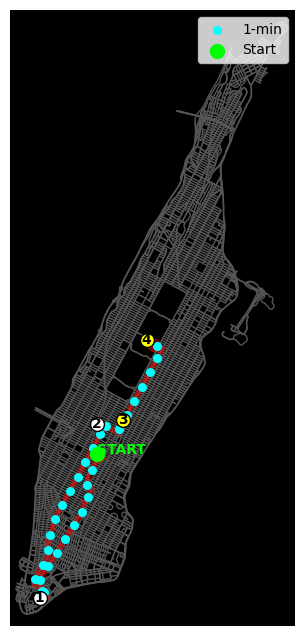

In [2]:
# Request A: Times Square -> Central Park
s1 = Stop(request_id="A", lat=40.7580, lon=-73.9855, is_pickup=True)
s2 = Stop(request_id="A", lat=40.7829, lon=-73.9654, is_pickup=False)
# Request B: Wall St -> Midtown
s3 = Stop(request_id="B", lat=40.7060, lon=-74.0088, is_pickup=True)
s4 = Stop(request_id="B", lat=40.7589, lon=-73.9750, is_pickup=False)
stops_list = [s1, s2, s3, s4]

# Vehicle Starts at Empire State
vehicle_start = (40.748817, -73.985428)
start_time = datetime.now()  # 3. Initialize Route
print("Initializing Route...")
route = Route(
    G, stops_list, vehicle_start, start_time, speed_mph=20
)  # 4. Generate (Solves TSP + Routes)
print("Solving Optimal Sequence & Generating Path...")
route.generate_route()  # 5. Outputs
print("\n--- RESULTS ---")
print("Optimal Sequence:", route.get_optimal_sequence())
print("Total Duration:", route.get_total_duration(), "mins")

print("\n--- STOP TIMETABLE ---")
df = route.get_optimal_time()
print(df)  # Query Location
query_t = start_time + timedelta(minutes=10)
loc = route.get_location_at_time(query_t)
print(f"\nLocation at +10 mins: {loc}")  # 6. Plot
route.plot_route_final()

---

---

# Simulation

Here is the detailed documentation for the classes in the final `rideshare_full_sim.py`.

### 1. Class: `SimulationLogger`
**Purpose:** Centralized File I/O handler to manage CSV logging efficiently, preventing performance bottlenecks associated with frequent file operations.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.log_dir` | `str` | Directory path for logs (default: `"./logs/"`). |
| `self.driver_file` | `str` | Path to the driver log file. |
| `self.request_file` | `str` | Path to the request log file. |
| `self.d_writer` | `csv.writer` | The CSV writer object linked to the driver log stream. |
| `self.r_writer` | `csv.writer` | The CSV writer object linked to the request log stream. |
| `self.d_handle` | `TextIOWrapper` | The open file handle for the driver log. |
| `self.r_handle` | `TextIOWrapper` | The open file handle for the request log. |

#### **Functions**
* **`initialize(self)`**
    * **Logic:** Creates the log directory if it doesn't exist. Opens both CSV files in write mode (`'w'`). Writes the header row for drivers and requests.
* **`log_driver_event(self, driver_id, category, time, route_seq, capacity="")`**
    * **Logic:** Formats the timestamp and appends a single row to the driver CSV. Used for events like shift starts, route updates, or finishing a shift. Captures capacity for analysis. Flushes buffer immediately.
* **`log_request_summary(self, req)`**
    * **Logic:** Called when a request is `COMPLETED`. Extracts all lifecycle data (ID, times, locations) from the `Request` object and writes a summary row. Flushes buffer immediately.
* **`close(self)`**
    * **Logic:** Flushes and closes the active file handles to ensure data is saved.

---

### 2. Class: `Stop`
**Purpose:** A data structure representing a specific physical node in the routing graph associated with a specific request.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.request_id` | `str` or `int` | The ID of the request this stop belongs to. |
| `self.lat` | `float` | Latitude of the physical location. |
| `self.lon` | `float` | Longitude of the physical location. |
| `self.is_pickup` | `bool` | `True` if this is a pickup location; `False` if it is a drop-off. Critical for precedence constraints. |
| `self.count` | `int` | The number of passengers boarding (if pickup) or alighting (if dropoff) at this specific stop. Used by the solver for dynamic load calculation. |

#### **Functions**
* **`__init__(self, request_id, lat, lon, is_pickup, count)`**: Constructor to initialize all attributes.
* **`__repr__(self)`**
    * **Returns:** A string representation (e.g., `<Stop R1 (2p): PICKUP>`) used for generating readable route sequence strings.

---

### 3. Class: `Request`
**Purpose:** Represents a passenger order and acts as a state machine tracking the order's lifecycle from creation to completion.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.id` | `str` | Unique identifier for the request. |
| `self.request_time` | `datetime` | The simulation time when the request was created. |
| `self.count` | `int` | Number of passengers in the party. |
| `self.pickup_loc` | `Stop` | The `Stop` object for the origin (initialized with `self.count`). |
| `self.dropoff_loc` | `Stop` | The `Stop` object for the destination (initialized with `self.count`). |
| `self.status` | `str` | Current state: `'PENDING'`, `'ACCEPTED'`, `'ON_BOARD'`, or `'COMPLETED'`. |
| `self.expected_pickup_time` | `datetime` | Estimated pickup time (set on first assignment). |
| `self.expected_dropoff_time` | `datetime` | Estimated drop-off time (set on first assignment). |
| `self.actual_pickup_time` | `datetime` | The exact time the driver arrived at the pickup. |
| `self.actual_dropoff_time` | `datetime` | The exact time the driver arrived at the drop-off. |

#### **Functions**
* **`update_expected_times(self, p_time, d_time)`**
    * **Logic:** Updates the expected times **only if they are currently None**. This preserves the original "promise" made to the passenger when they were first assigned, allowing for accurate delay calculation later.
* **`record_pickup(self, time)`**
    * **Logic:** Sets `self.actual_pickup_time` and changes status to `'ON_BOARD'`. Guards against double-recording.
* **`record_dropoff(self, time)`**
    * **Logic:** Sets `self.actual_dropoff_time` and changes status to `'COMPLETED'`.

---

### 4. Class: `Route`
**Purpose:** The computational engine. It handles the mathematical optimization (TSP) and the geometric pathfinding using the road network.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.G_latlon` | `MultiDiGraph` | Reference to the unprojected OSMnx graph. |
| `self.G_proj` | `MultiDiGraph` | Reference to the projected (meters) graph used for distance calculations. |
| `self.all_stops` | `List[Stop]` | The pool of locations to visit. |
| `self.start_coords` | `Tuple[float, float]` | The vehicle's starting location for this specific calculation. |
| `self.start_time` | `datetime` | The time the vehicle starts this route segment. |
| `self.speed_mps` | `float` | Vehicle speed in meters per second. |
| `self.vehicle_capacity` | `int` | **Dynamic Constraint:** The max capacity of the specific vehicle requesting this route. |
| `self.initial_load` | `int` | **Dynamic Constraint:** The number of passengers currently inside the vehicle at the start of calculation. |
| `self.optimal_sequence` | `List[Stop]` | The ordered list of stops derived from the solver. |
| `self.stop_arrival_times` | `List[datetime]` | Arrival times corresponding to the `optimal_sequence`. |
| `self.route_line` | `LineString` | The continuous geometry of the path (for interpolation). |
| `self.total_distance` | `float` | Total length of the route in meters. |
| `self.route_nodes` | `List[int]` | Sequence of OSM node IDs representing the path. |

#### **Functions**
* **`_solve_tsp_gurobi(self)`**
    * **Logic:** Constructs a Mixed Integer Linear Program (MILP) to solve the Open Traveling Salesperson Problem.
    * **Constraints:**
        1.  **Flow:** Path starts at 0, visits all nodes, does not return.
        2.  **Precedence:** `Pickup_Index < Dropoff_Index` for every request ID.
        3.  **Initial Load:** The load variable at the start node (`l[0]`) is forced to equal `self.initial_load`.
        4.  **Capacity:** For every node visit $j$, the load updates: $l[j] = l[i] \pm stop.count$. Constraint: $l[j] \le self.vehicle\_capacity$.
* **`generate_route(self)`**
    * **Logic:** Calls solver. If feasible, uses `nx.shortest_path` to find paths between stops. Stitches geometry. Returns `False` if infeasible or path empty.
* **`get_location_at_time(self, query_time)`**
    * **Logic:** Interpolates exact coordinate along the path based on elapsed time and speed.
* **`get_optimal_time(self)`**
    * **Logic:** Returns a pandas DataFrame containing the schedule (Stop details + Arrival Times).
* **`get_sequence_string(self)`**
    * **Logic:** Returns a formatted string of the stop sequence.
* **`plot_route_final(self)`**
    * **Logic:** Visualizes the route and stops on the map.

---

### 5. Class: `Driver`
**Purpose:** An autonomous agent that moves through the simulation, manages individual capacity/load, and evaluates new requests.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.id` | `str` | Unique Driver ID (e.g., "D1"). |
| `self.current_location` | `Tuple[float, float]` | Current position (lat, lon). |
| `self.start_shift_time` | `datetime` | Time the driver started their shift. |
| `self.accepting_orders` | `bool` | `True` if within shift limits; `False` if "retired". |
| `self.capacity` | `int` | **Dynamic Attribute:** Seat capacity assigned to this specific driver. |
| `self.passengers_on_board` | `int` | Current passenger count inside the vehicle. |
| `self.active_requests` | `List[Request]` | Requests currently assigned (either picked up or waiting). |
| `self.route` | `Route` | The active `Route` object. `None` if idle. |
| `self.last_update_time` | `datetime` | Timestamp of the last status update. |
| `self.is_idle` | `bool` | `True` if the driver has no active route. |
| `self.speed` | `float` | Average driving speed (mph). |

#### **Functions**
* **`_get_unvisited_stops(self, current_time)`**
    * **Logic:** Filters the current route's stop list. Returns stops where the associated request action (pickup or dropoff) has **not yet happened** (checked via `req.actual_pickup_time` etc.).
* **`status_update(self, current_time, logger)`**
    * **Logic (The "Heartbeat"):**
        1.  Updates `current_location` via interpolation.
        2.  Iterates through schedule. If stop time $\le$ `current_time`, triggers record/update logic.
        3.  Checks if route finished. If so, sets `is_idle=True`.
        4.  **Returns:** List of requests that completed this tick.
* **`request_validity_check(self, new_req, current_time)`**
    * **Logic (Feasibility):**
        1.  **Pre-check:** If `new_req.count > self.capacity`, return `None`.
        2.  Create hypothetical stop pool: `[Unvisited Stops] + [New Pickup, New Dropoff]`.
        3.  Instantiates `Route` passing `initial_load=self.passengers_on_board`.
        4.  If `generate_route()` fails, return `None`.
        5.  **Delay Check:** Ensure new route doesn't delay existing passengers > 20%.
* **`accept_request(self, req, potential_route, logger)`**
    * **Logic:** Adds `req` to active list. Replaces `self.route`. Updates expected times for all active passengers. Logs event.

---

### 6. Class: `Simulation`
**Purpose:** The Master Controller managing global time, fleet lifecycle, and dispatching.

#### **Attributes**
| Variable Name | Data Type | Description |
| :--- | :--- | :--- |
| `self.start_time` | `datetime` | Simulation start time. |
| `self.end_time` | `datetime` | Simulation end time. |
| `self.time_step` | `timedelta` | Step size (1 minute). |
| `self.current_time` | `datetime` | Current clock time. |
| `self.request_data` | `List[Dict]` | Raw input data for requests. |
| `self.pending_requests` | `List[Request]` | Queue of unassigned requests. |
| `self.vehicles` | `List[Driver]` | List of active driver objects. |
| `self.logger` | `SimulationLogger` | Logging handler. |
| `self.driver_schedule` | `Dict[int, int]` | Mapping of {Hour: Target_Driver_Count}. |
| `self.shift_hours` | `int` | Max duration a driver can work. |
| `self.start_loc_pool` | `List[Tuple]` | Pool of possible spawn coordinates. |
| `self.vehicle_capacity_types` | `List[int]` | List of capacities (e.g., `[4, 6]`) to randomly assign to new drivers. |

#### **Functions**
* **`initialize(self)`**
    * **Logic:** Sets up logger, loads map, projects graph, spawns initial fleet.
* **`add_drivers(self, count)`**
    * **Logic:** Instantiates `count` new `Driver` objects. Randomly selects start location and capacity. Logs "SHIFT_START".
* **`manage_fleet(self)`**
    * **Logic (Run Hourly):** Adds drivers if under target. Retires drivers over shift limit. Removes retired idle drivers.
* **`get_new_requests(self, t_start, t_end)`**
    * **Logic:** Filters raw `request_data` for requests in current window.
* **`find_best_vehicle(self, req)`**
    * **Logic (Greedy Dispatch):** Iterates all drivers. Calls `request_validity_check`. Selects driver with earliest pickup time.
* **`run_simulation(self)`**
    * **Logic (Main Loop):** Calls `manage_fleet`, `status_update`, gets new requests, assigns pending requests, increments time, closes logger.

---

In [3]:
import osmnx as ox
import networkx as nx
from shapely.geometry import LineString, Point
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
import math
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import csv
import os
import random

# Suppress warnings
warnings.filterwarnings("ignore")

# https://www.nyc.gov/html/dot/downloads/pdf/mobility-report-singlepage-2019.pdf
DYNAMIC_SPEED_SCHEDULE = {
    0: 11.0,  # 00:00–01:00  late night, fairly free
    1: 11.0,  # 01:00–02:00
    2: 11.0,  # 02:00–03:00
    3: 11.0,  # 03:00–04:00 (best conditions)
    4: 10.0,  # 04:00–05:00  still very good
    5: 9.0,  # 05:00–06:00
    6: 8.0,  # 06:00–07:00  traffic building
    7: 6.0,  # 07:00–08:00  AM peak
    8: 6.0,  # 08:00–09:00  AM peak
    9: 7.0,  # 09:00–10:00  easing a bit
    10: 7.0,  # 10:00–11:00
    11: 8.0,  # 11:00–12:00
    12: 9.0,  # 12:00–13:00  midday fairly smooth
    13: 9.0,  # 13:00–14:00
    14: 8.0,  # 14:00–15:00
    15: 8.0,  # 15:00–16:00  heading into PM peak
    16: 7.0,  # 16:00–17:00  PM peak
    17: 6.0,  # 17:00–18:00  worst PM peak
    18: 7.0,  # 18:00–19:00  recovering
    19: 8.0,  # 19:00–20:00
    20: 9.0,  # 20:00–21:00
    21: 10.0,  # 21:00–22:00
    22: 10.0,  # 22:00–23:00
    23: 11.0,  # 23:00–24:00  close to overnight free flow
}


# ==========================================
# 1. LOGGER CLASS
# ==========================================
class SimulationLogger:
    def __init__(self):
        self.driver_file = "./logs/driver_logs.csv"
        self.request_file = "./logs/request_logs.csv"
        self.d_writer = None
        self.r_writer = None
        self.d_handle = None
        self.r_handle = None

    def initialize(self):
        self.d_handle = open(self.driver_file, mode="w", newline="")
        self.d_writer = csv.writer(self.d_handle)
        self.d_writer.writerow(
            ["Driver_ID", "Category", "Time", "Route_Sequence", "Capacity"]
        )

        self.r_handle = open(self.request_file, mode="w", newline="")
        self.r_writer = csv.writer(self.r_handle)
        self.r_writer.writerow(
            [
                "Request_ID",
                "Request_Time",
                "Status",
                "Passengers",
                "Pickup_Lat",
                "Pickup_Lon",
                "Dropoff_Lat",
                "Dropoff_Lon",
                "Exp_Pickup_Time",
                "Exp_Dropoff_Time",
                "Act_Pickup_Time",
                "Act_Dropoff_Time",
            ]
        )
        print("Logger Initialized. Writing to CSVs...")

    def log_driver_event(self, driver_id, category, time, route_seq, capacity=""):
        t_str = time.strftime("%Y-%m-%d %H:%M:%S")
        self.d_writer.writerow([driver_id, category, t_str, route_seq, capacity])

    def log_request_summary(self, req):
        fmt = lambda t: t.strftime("%Y-%m-%d %H:%M:%S") if t else ""
        self.r_writer.writerow(
            [
                req.id,
                fmt(req.request_time),
                req.status,
                req.count,
                req.pickup_loc.lat,
                req.pickup_loc.lon,
                req.dropoff_loc.lat,
                req.dropoff_loc.lon,
                fmt(req.expected_pickup_time),
                fmt(req.expected_dropoff_time),
                fmt(req.actual_pickup_time),
                fmt(req.actual_dropoff_time),
            ]
        )

    def close(self):
        if self.d_handle:
            self.d_handle.close()
        if self.r_handle:
            self.r_handle.close()
        print("Logs closed.")


# ==========================================
# 2. STOP & REQUEST CLASSES
# ==========================================
class Stop:
    def __init__(self, request_id, lat, lon, is_pickup, count):
        self.request_id = request_id
        self.lat = lat
        self.lon = lon
        self.is_pickup = is_pickup
        self.count = count

    def __repr__(self):
        type_str = "PICKUP" if self.is_pickup else "DROPOFF"
        return f"<Stop {self.request_id} ({self.count}p): {type_str}>"


class Request:
    def __init__(self, req_id, request_time, count, p_lat, p_lon, d_lat, d_lon):
        self.id = req_id
        self.request_time = request_time
        self.count = count

        self.pickup_loc = Stop(req_id, p_lat, p_lon, True, count)
        self.dropoff_loc = Stop(req_id, d_lat, d_lon, False, count)

        self.status = "PENDING"

        self.expected_pickup_time = None
        self.expected_dropoff_time = None
        self.actual_pickup_time = None
        self.actual_dropoff_time = None

    def update_expected_times(self, p_time, d_time):
        # FIX: Only update if None
        if self.expected_pickup_time is None:
            self.expected_pickup_time = p_time
        if self.expected_dropoff_time is None:
            self.expected_dropoff_time = d_time

    def record_pickup(self, time):
        if self.actual_pickup_time is None:
            self.actual_pickup_time = time
            self.status = "ON_BOARD"

    def record_dropoff(self, time):
        if self.actual_dropoff_time is None:
            self.actual_dropoff_time = time
            self.status = "COMPLETED"


# ==========================================
# 3. ROUTE CLASS
# ==========================================
class Route:
    def __init__(
        self,
        G,
        stops,
        vehicle_start_coords,
        start_time,
        speed_mph,
        vehicle_capacity,
        initial_load=0,
    ):
        self.G_latlon = G
        self.all_stops = stops
        self.start_coords = vehicle_start_coords
        self.start_time = start_time
        self.speed_mps = speed_mph * 0.44704  # convert to m/s
        self.vehicle_capacity = vehicle_capacity
        self.initial_load = initial_load

        self.optimal_sequence = []
        self.stop_arrival_times = []
        self.route_line = None
        self.total_distance = 0
        self.G_proj = None
        self.route_nodes = []

        self.G_proj = ox.project_graph(G)

    def _solve_tsp_gurobi(self):
        node_list = [
            {
                "lat": self.start_coords[0],
                "lon": self.start_coords[1],
                "type": "start",
                "id": "start",
            }
        ]
        req_to_pickup_idx = {}
        req_to_dropoff_idx = {}

        for i, stop in enumerate(self.all_stops):
            idx = i + 1
            node_list.append({"lat": stop.lat, "lon": stop.lon, "obj": stop})
            if stop.is_pickup:
                req_to_pickup_idx[stop.request_id] = idx
            else:
                req_to_dropoff_idx[stop.request_id] = idx

        n = len(node_list)
        capacity = self.vehicle_capacity

        import pyproj

        transformer = pyproj.Transformer.from_crs(
            self.G_latlon.graph["crs"], self.G_proj.graph["crs"], always_xy=True
        )
        coords_xy = []
        for node in node_list:
            x, y = transformer.transform(node["lon"], node["lat"])
            coords_xy.append((x, y))

        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    dist[i, j] = abs(coords_xy[i][0] - coords_xy[j][0]) + abs(
                        coords_xy[i][1] - coords_xy[j][1]
                    )

        # m = gp.Model("Rideshare_TSP")
        # m.setParam('OutputFlag', 0)
        m = gp.Model("Rideshare_TSP")
        m.setParam("OutputFlag", 0)
        m.setParam("TimeLimit", 90.0)  # 1.5 minutes max

        x = m.addVars(n, n, vtype=GRB.BINARY, name="x")
        u = m.addVars(n, vtype=GRB.CONTINUOUS, lb=0, ub=n, name="u")
        l = m.addVars(n, vtype=GRB.CONTINUOUS, lb=0, ub=capacity, name="load")

        m.setObjective(
            gp.quicksum(dist[i, j] * x[i, j] for i in range(n) for j in range(n)),
            GRB.MINIMIZE,
        )

        m.addConstr(gp.quicksum(x[0, j] for j in range(1, n)) == 1, name="Start_Leave")
        m.addConstr(gp.quicksum(x[i, 0] for i in range(n)) == 0, name="Start_Enter")
        for j in range(1, n):
            m.addConstr(
                gp.quicksum(x[i, j] for i in range(n) if i != j) == 1, name=f"Enter_{j}"
            )
        for i in range(1, n):
            m.addConstr(
                gp.quicksum(x[i, j] for j in range(1, n) if i != j) <= 1,
                name=f"Leave_{i}",
            )

        m.addConstr(
            gp.quicksum(x[i, j] for i in range(n) for j in range(n)) == n - 1,
            name="Total_Edges",
        )

        m.addConstr(u[0] == 0, name="Start_Order")
        for i in range(1, n):
            for j in range(1, n):
                if i != j:
                    m.addConstr(u[i] - u[j] + n * x[i, j] <= n - 1)

        for req_id, p_idx in req_to_pickup_idx.items():
            if req_id in req_to_dropoff_idx:
                d_idx = req_to_dropoff_idx[req_id]
                m.addConstr(u[p_idx] <= u[d_idx] - 1)

        m.addConstr(l[0] == self.initial_load, name="Initial_Load")

        for i in range(n):
            for j in range(1, n):
                if i != j:
                    change = 0
                    stop_obj = node_list[j].get("obj")
                    if stop_obj:
                        if stop_obj.is_pickup:
                            change = stop_obj.count
                        else:
                            change = -stop_obj.count

                    M = capacity + 10
                    m.addConstr(l[j] >= l[i] + change - M * (1 - x[i, j]))
                    m.addConstr(l[j] <= l[i] + change + M * (1 - x[i, j]))

        m.optimize()

        # if m.status == GRB.OPTIMAL:
        #     seq_indices = [0]
        #     curr = 0
        #     while True:
        #         found_next = False
        #         for j in range(n):
        #             if curr != j and x[curr, j].X > 0.5:
        #                 seq_indices.append(j)
        #                 curr = j
        #                 found_next = True
        #                 break
        #         if not found_next: break
        #     self.optimal_sequence = [node_list[i]['obj'] for i in seq_indices if i != 0]
        #     return True
        # else:
        #     return False

        # Accept if optimal OR time limit but at least one feasible solution found
        if m.status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount > 0:
            if m.status == GRB.TIME_LIMIT:
                print("[MILP] Time limit reached, using incumbent solution.")
            seq_indices = [0]
            curr = 0
            while True:
                found_next = False
                for j in range(n):
                    if curr != j and x[curr, j].X > 0.5:
                        seq_indices.append(j)
                        curr = j
                        found_next = True
                        break
                if not found_next:
                    break
            self.optimal_sequence = [node_list[i]["obj"] for i in seq_indices if i != 0]
            return True
        else:
            # No feasible solution in time (or model infeasible, etc.)
            return False

    def generate_route(self):
        if not self._solve_tsp_gurobi():
            return False

        full_pts = []
        self.route_nodes = []
        routing_seq = [self.start_coords] + [
            (s.lat, s.lon) for s in self.optimal_sequence
        ]
        curr_dist = 0
        self.stop_arrival_times = []

        import pyproj

        transformer = pyproj.Transformer.from_crs(
            self.G_latlon.graph["crs"], self.G_proj.graph["crs"], always_xy=True
        )

        for i in range(len(routing_seq) - 1):
            s_lat, s_lon = routing_seq[i]
            e_lat, e_lon = routing_seq[i + 1]

            sx, sy = transformer.transform(s_lon, s_lat)
            ex, ey = transformer.transform(e_lon, e_lat)

            orig = ox.nearest_nodes(self.G_proj, sx, sy)
            dest = ox.nearest_nodes(self.G_proj, ex, ey)

            try:
                nodes = nx.shortest_path(self.G_proj, orig, dest, weight="length")

                if i > 0:
                    self.route_nodes.extend(nodes[1:])
                else:
                    self.route_nodes.extend(nodes)

                pts = [
                    (self.G_proj.nodes[n]["x"], self.G_proj.nodes[n]["y"])
                    for n in nodes
                ]

                seg_len = LineString(pts).length if len(pts) >= 2 else 0
                curr_dist += seg_len
                self.stop_arrival_times.append(
                    self.start_time + timedelta(seconds=curr_dist / self.speed_mps)
                )

                if i > 0:
                    full_pts.extend(pts[1:])
                else:
                    full_pts.extend(pts)
            except:
                self.stop_arrival_times.append(
                    self.stop_arrival_times[-1]
                    if self.stop_arrival_times
                    else self.start_time
                )

        if not full_pts:
            return False

        if len(full_pts) < 2:
            full_pts.append(full_pts[0])
        self.route_line = LineString(full_pts)
        self.total_distance = self.route_line.length
        return True

    def get_location_at_time(self, query_time):
        if not self.route_line:
            return self.start_coords
        time_elapsed = (query_time - self.start_time).total_seconds()
        if time_elapsed <= 0:
            return self.start_coords
        dist_traveled = time_elapsed * self.speed_mps
        if dist_traveled >= self.total_distance:
            return (
                (self.optimal_sequence[-1].lat, self.optimal_sequence[-1].lon)
                if self.optimal_sequence
                else self.start_coords
            )

        point = self.route_line.interpolate(dist_traveled)
        import pyproj

        transformer = pyproj.Transformer.from_crs(
            self.G_proj.graph["crs"], "EPSG:4326", always_xy=True
        )
        lon, lat = transformer.transform(point.x, point.y)
        return (lat, lon)

    def get_total_duration(self):
        if self.total_distance == 0:
            return 0.0
        total_seconds = self.total_distance / self.speed_mps
        return round(total_seconds / 60, 2)

    def get_optimal_sequence(self):
        return self.optimal_sequence

    def get_optimal_time(self):
        if not self.optimal_sequence or not self.stop_arrival_times:
            return pd.DataFrame()

        data = []
        for i, (stop, time) in enumerate(
            zip(self.optimal_sequence, self.stop_arrival_times)
        ):
            data.append(
                {
                    "Step": i + 1,
                    "Request ID": stop.request_id,
                    "Type": "PICKUP" if stop.is_pickup else "DROPOFF",
                    "Lat": stop.lat,
                    "Lon": stop.lon,
                    "Arrival Time": time.strftime("%H:%M:%S"),
                }
            )
        return pd.DataFrame(data)

    def get_sequence_string(self):
        return " -> ".join([str(s) for s in self.optimal_sequence])

    def plot_route_final(self):
        if not self.G_proj or not self.route_nodes:
            return

        fig, ax = ox.plot_graph_route(
            self.G_proj,
            self.route_nodes,
            route_color="r",
            route_linewidth=4,
            node_size=0,
            bgcolor="k",
            edge_color="#555555",
            show=False,
            close=False,
        )

        marker_x, marker_y = [], []
        total_minutes = int(self.get_total_duration())

        for i in range(1, total_minutes + 1):
            dist = i * 60 * self.speed_mps
            point = self.route_line.interpolate(dist)
            marker_x.append(point.x)
            marker_y.append(point.y)

        ax.scatter(marker_x, marker_y, c="cyan", s=30, zorder=5, label="1-min")

        import pyproj

        transformer = pyproj.Transformer.from_crs(
            "EPSG:4326", self.G_proj.graph["crs"], always_xy=True
        )

        sx, sy = transformer.transform(self.start_coords[1], self.start_coords[0])
        ax.scatter(sx, sy, c="lime", s=100, zorder=10, label="Start")
        ax.text(sx, sy, "START", color="lime", fontweight="bold", zorder=12)

        for i, stop in enumerate(self.optimal_sequence):
            sx, sy = transformer.transform(stop.lon, stop.lat)
            color = "white" if stop.is_pickup else "yellow"
            ax.scatter(sx, sy, c=color, s=100, zorder=10, edgecolors="black")
            ax.text(
                sx,
                sy,
                f"{i + 1}",
                color="black",
                fontweight="bold",
                ha="center",
                va="center",
                zorder=11,
            )

        plt.legend()
        plt.show()


# ==========================================
# 4. DRIVER CLASS
# ==========================================
class Driver:
    # def __init__(self, d_id, start_loc, start_shift_time, G_latlon, G_proj, capacity):
    def __init__(
        self,
        d_id,
        start_loc,
        start_shift_time,
        G_latlon,
        G_proj,
        capacity,
        speed_schedule,
    ):
        self.id = d_id
        self.current_location = start_loc
        self.start_shift_time = start_shift_time
        self.accepting_orders = True

        self.G_latlon = G_latlon
        self.G_proj = G_proj
        self.capacity = capacity

        self.passengers_on_board = 0
        self.active_requests = []
        self.route = None
        self.last_update_time = None
        self.is_idle = True

        # self.speed = 20 # SPEED CHANGE OVER HERE
        self.speed_schedule = speed_schedule  # dict of hour:int speed_mph

    def _get_unvisited_stops(self, current_time):
        if not self.route:
            return []

        # CRITICAL FIX: Filter based on Request State (Has action occurred?), NOT just time.
        # This prevents stops at the exact current second from being dropped erroneously.
        future_stops = []
        for stop in self.route.optimal_sequence:
            # Find the associated request in active list
            req = next(
                (r for r in self.active_requests if r.id == stop.request_id), None
            )

            if req:
                if stop.is_pickup:
                    # Include if pickup hasn't happened yet
                    if req.actual_pickup_time is None:
                        future_stops.append(stop)
                else:
                    # Include if dropoff hasn't happened yet
                    if req.actual_dropoff_time is None:
                        future_stops.append(stop)

        return future_stops

    def status_update(self, current_time, logger):
        self.last_update_time = current_time
        completed_requests_this_tick = []

        if self.is_idle or not self.route:
            return completed_requests_this_tick

        self.current_location = self.route.get_location_at_time(current_time)

        for i, (stop, t) in enumerate(
            zip(self.route.optimal_sequence, self.route.stop_arrival_times)
        ):
            if t <= current_time:
                req = next(
                    (r for r in self.active_requests if r.id == stop.request_id), None
                )
                if req:
                    if stop.is_pickup and req.actual_pickup_time is None:
                        req.record_pickup(t)
                        self.passengers_on_board += req.count
                    elif not stop.is_pickup and req.actual_dropoff_time is None:
                        req.record_dropoff(t)
                        self.passengers_on_board -= req.count
                        if req.status == "COMPLETED":
                            completed_requests_this_tick.append(req)

        if (
            self.route.stop_arrival_times
            and self.route.stop_arrival_times[-1] <= current_time
        ):
            logger.log_driver_event(
                self.id,
                "FINISH",
                current_time,
                self.route.get_sequence_string(),
                self.capacity,
            )
            self.is_idle = True
            self.route = None
            self.active_requests = [
                r for r in self.active_requests if r.status != "COMPLETED"
            ]

        return completed_requests_this_tick

    def request_validity_check(self, new_req, current_time):
        if not self.accepting_orders:
            return None

        # PRE-CHECK: Only check if group size fits TOTAL capacity.
        # Current load checks are handled by MILP (to account for dropoffs).
        if new_req.count > self.capacity:
            return None

        future = self._get_unvisited_stops(current_time)
        pool = future + [new_req.pickup_loc, new_req.dropoff_loc]

        current_hour = current_time.hour
        current_speed = self.speed_schedule.get(
            current_hour, 10
        )  # default to 10 mph if hour not found
        # current_speed = self.speed_schedule.get(current_hour)

        temp_route = Route(
            self.G_latlon,
            pool,
            self.current_location,
            current_time,
            # self.speed,
            current_speed,
            self.capacity,
            initial_load=self.passengers_on_board,
        )

        if not temp_route.generate_route():
            return None

        for req in self.active_requests:
            if req.status == "COMPLETED":
                continue

            new_drop_time = None
            for stop, t in zip(
                temp_route.optimal_sequence, temp_route.stop_arrival_times
            ):
                if stop.request_id == req.id and not stop.is_pickup:
                    new_drop_time = t
                    break

            if not new_drop_time:
                continue

            if req.expected_dropoff_time:
                old_duration = (
                    req.expected_dropoff_time - req.request_time
                ).total_seconds()
                new_duration = (new_drop_time - req.request_time).total_seconds()

                if old_duration > 60 and new_duration > (
                    old_duration * 1.2
                ):  # only protect if original was > 1min
                    return None

        return temp_route

    # def accept_request(self, req, potential_route, logger):
    def accept_request(self, req, potential_route, logger, current_time):
        cat = "NEW_ROUTE" if self.is_idle else "UPDATE_ROUTE"

        self.active_requests.append(req)
        self.route = potential_route
        self.is_idle = False

        for r in self.active_requests:
            if r.status == "COMPLETED":
                continue
            p_time = None
            d_time = None

            for stop, t in zip(
                self.route.optimal_sequence, self.route.stop_arrival_times
            ):
                if stop.request_id == r.id:
                    if stop.is_pickup:
                        p_time = t
                    else:
                        d_time = t

            if not p_time:
                p_time = r.expected_pickup_time
            if not d_time:
                d_time = r.expected_dropoff_time

            r.update_expected_times(p_time, d_time)
        # If a driver is created at 18:00 and you assign them a request that was requested at 17:58, the log line shows a route event at 17:58
        # logger.log_driver_event(self.id, cat, req.request_time, self.route.get_sequence_string(), self.capacity)
        logger.log_driver_event(
            self.id, cat, current_time, self.route.get_sequence_string(), self.capacity
        )


# ==========================================
# 5. SIMULATION CLASS
# ==========================================
class Simulation:
    # def __init__(self, start, end, request_data, driver_schedule, shift_hours=8, start_locations=None, vehicle_capacity_types=[4]):
    def __init__(
        self,
        start,
        end,
        request_data,
        driver_schedule,
        shift_hours=8,
        start_locations=None,
        vehicle_capacity_types=[4],
        speed_schedule=None,
    ):
        self.speed_schedule = (
            speed_schedule if speed_schedule is not None else DYNAMIC_SPEED_SCHEDULE
        )

        self.start_time = start
        self.end_time = end
        self.time_step = timedelta(minutes=1)
        self.current_time = start

        self.request_data = request_data
        self.pending_requests = []
        self.vehicles = []
        self.logger = SimulationLogger()

        self.G_latlon = None
        self.G_proj = None

        self.driver_schedule = driver_schedule
        self.shift_hours = shift_hours
        self.driver_counter = 0
        self.vehicle_capacity_types = vehicle_capacity_types

        if start_locations:
            self.start_loc_pool = start_locations
        else:
            self.start_loc_pool = [(40.748817, -73.985428)]

    def initialize(self):
        self.logger.initialize()

        if os.path.exists("manhattan.graphml"):
            print("Loading Map...")
            self.G_latlon = ox.load_graphml("manhattan.graphml")
        else:
            print("Downloading Map...")
            self.G_latlon = ox.graph_from_place(
                "Manhattan, New York, USA", network_type="drive"
            )
            ox.save_graphml(self.G_latlon, "manhattan.graphml")

        self.G_proj = ox.project_graph(self.G_latlon)

        current_hour = self.start_time.hour
        target_drivers = self.driver_schedule.get(current_hour, 5)
        self.add_drivers(target_drivers)

    def add_drivers(self, count):
        for _ in range(count):
            self.driver_counter += 1
            d_id = f"D{self.driver_counter}"
            loc = random.choice(self.start_loc_pool)
            cap = random.choice(self.vehicle_capacity_types)
            # new_driver = Driver(d_id, loc, self.current_time, self.G_latlon, self.G_proj, capacity=cap)
            new_driver = Driver(
                d_id,
                loc,
                self.current_time,
                self.G_latlon,
                self.G_proj,
                capacity=cap,
                speed_schedule=self.speed_schedule,
            )
            self.vehicles.append(new_driver)
            self.logger.log_driver_event(
                d_id, "SHIFT_START", self.current_time, "INIT", cap
            )
        if count > 0:
            print(
                f"[{self.current_time.strftime('%H:%M')}] Added {count} drivers. Total: {len(self.vehicles)}"
            )

    def manage_fleet(self):
        current_hour = self.current_time.hour
        target_count = self.driver_schedule.get(current_hour, 5)

        active_drivers = [d for d in self.vehicles if d.accepting_orders]
        if len(active_drivers) < target_count:
            needed = target_count - len(active_drivers)
            self.add_drivers(needed)

        for d in self.vehicles:
            if d.accepting_orders:
                hours_worked = (
                    self.current_time - d.start_shift_time
                ).total_seconds() / 3600.0
                if hours_worked >= self.shift_hours:
                    d.accepting_orders = False
                    self.logger.log_driver_event(
                        d.id,
                        "SHIFT_END_PENDING",
                        self.current_time,
                        "Finishing Last Route",
                        d.capacity,
                    )

        remaining_vehicles = []
        for d in self.vehicles:
            if not d.accepting_orders and d.is_idle:
                self.logger.log_driver_event(
                    d.id,
                    "OFF_DUTY",
                    self.current_time,
                    "Removed from Fleet",
                    d.capacity,
                )
            else:
                remaining_vehicles.append(d)

        if len(remaining_vehicles) != len(self.vehicles):
            print(
                f"[{self.current_time.strftime('%H:%M')}] Removed {len(self.vehicles) - len(remaining_vehicles)} drivers. Total: {len(remaining_vehicles)}"
            )

        self.vehicles = remaining_vehicles

    def get_new_requests(self, t_start, t_end):
        new = []
        for r_dict in self.request_data:
            rt = r_dict["time"]
            if t_start <= rt < t_end:
                req = Request(
                    r_dict["id"],
                    rt,
                    r_dict["count"],
                    r_dict["p_lat"],
                    r_dict["p_lon"],
                    r_dict["d_lat"],
                    r_dict["d_lon"],
                )
                new.append(req)
        return new

    def find_best_vehicle(self, req):
        best_driver = None
        best_route = None
        best_pickup_time = datetime.max

        for driver in self.vehicles:
            pot_route = driver.request_validity_check(req, self.current_time)

            if pot_route:
                p_time = None
                for stop, t in zip(
                    pot_route.optimal_sequence, pot_route.stop_arrival_times
                ):
                    if stop.request_id == req.id and stop.is_pickup:
                        p_time = t
                        break

                if p_time and p_time < best_pickup_time:  # earliest pickup rule
                    best_pickup_time = p_time
                    best_driver = driver
                    best_route = pot_route

        return best_driver, best_route

    def run_simulation(self):
        print("Starting Simulation Loop...")

        while self.current_time < self.end_time:
            if self.current_time.minute == 0:
                self.manage_fleet()

            for v in self.vehicles:
                completed_reqs = v.status_update(self.current_time, self.logger)
                for r in completed_reqs:
                    self.logger.log_request_summary(r)

            new_reqs = self.get_new_requests(
                self.current_time, self.current_time + self.time_step
            )
            self.pending_requests.extend(new_reqs)

            active_queue = list(self.pending_requests)

            for req in active_queue:
                driver, route = self.find_best_vehicle(req)

                if driver:
                    print(
                        f"[{self.current_time.strftime('%H:%M')}] Assigned {req.id} to {driver.id}"
                    )
                    # driver.accept_request(req, route, self.logger)
                    driver.accept_request(req, route, self.logger, self.current_time)
                    req.status = "ACCEPTED"
                    self.pending_requests.remove(req)
                else:
                    pass

            self.current_time += self.time_step

        self.logger.close()
        print("Simulation Complete.")

In [4]:
base_time = datetime(2025, 1, 1, 8, 0, 0)  # yyyy, mm, dd, hh, mm, ss

schedule_data = {8: 3, 9: 5}  # hour: number_of_drivers
my_custom_depots = [(40.7505, -73.9934)]  # Penn Station

req_data = [
    {
        "id": "R1",
        "time": base_time + timedelta(minutes=1),
        "count": 1,
        "p_lat": 40.7580,
        "p_lon": -73.9855,
        "d_lat": 40.7829,
        "d_lon": -73.9654,
    },
    {
        "id": "R2",
        "time": base_time + timedelta(minutes=5),
        "count": 2,
        "p_lat": 40.7060,
        "p_lon": -74.0088,
        "d_lat": 40.7589,
        "d_lon": -73.9750,
    },
    {
        "id": "R3",
        "time": base_time + timedelta(minutes=15),
        "count": 1,
        "p_lat": 40.8084,
        "p_lon": -73.9634,
        "d_lat": 40.7950,
        "d_lon": -73.9700,
    },
    {
        "id": "R4",
        "time": base_time + timedelta(minutes=20),
        "count": 1,
        "p_lat": 40.7484,
        "p_lon": -73.9857,
        "d_lat": 40.7127,
        "d_lon": -74.0134,
    },
    {
        "id": "R5",
        "time": base_time + timedelta(minutes=25),
        "count": 1,
        "p_lat": 40.7295,
        "p_lon": -73.9965,
        "d_lat": 40.7580,
        "d_lon": -73.9855,
    },
]

sim = Simulation(
    start=base_time,  # Simulation start time
    end=base_time + timedelta(hours=2),  # Simulation end time
    request_data=req_data,
    driver_schedule=schedule_data,  # custom driver schedule
    shift_hours=1,  # custom shift hours
    start_locations=my_custom_depots,  # Custom depots
    vehicle_capacity_types=[4, 6],  # Different vehicle capacities
)

sim.initialize()
sim.run_simulation()

Logger Initialized. Writing to CSVs...
Loading Map...
[08:00] Added 3 drivers. Total: 3
Starting Simulation Loop...
[08:01] Assigned R1 to D1
[08:05] Assigned R2 to D2
[08:15] Assigned R3 to D3
[08:20] Assigned R4 to D1
[08:25] Assigned R5 to D2
[09:00] Added 2 drivers. Total: 5
Logs closed.
Simulation Complete.


---

In [5]:
import pandas as pd
from datetime import datetime, timedelta


def prepare_simulation_data(start_time, end_time, rides_file, supply_file):
    """
    Reads rides and driver schedule data, filters for the given time range,
    and prepares the data structures required for the Simulation class.
    """
    print(f"--- Preparing Data for {start_time.date()} ---")
    print("Loading requests...")
    df_rides = pd.read_csv(rides_file)
    # Parse datetime (handles '1/1/2025 0:01' format automatically)
    df_rides["Request Creation Time"] = pd.to_datetime(
        df_rides["Request Creation Time"]
    )
    # Filter by time window
    mask = (df_rides["Request Creation Time"] >= start_time) & (
        df_rides["Request Creation Time"] <= end_time
    )
    df_subset = df_rides.loc[mask].sort_values("Request Creation Time")

    req_data = []
    for idx, row in df_subset.iterrows():
        req_data.append(
            {
                "id": f"R{idx}",
                "time": row["Request Creation Time"],
                "count": int(row.get("Number of Passengers", 1)),
                "p_lat": row["Origin Lat"],
                "p_lon": row["Origin Lng"],
                "d_lat": row["Destination Lat"],
                "d_lon": row["Destination Lng"],
            }
        )
    print(f" -> Loaded {len(req_data)} requests.")

    # 2. LOAD & PROCESS DRIVER SCHEDULE
    print("Loading driver schedule...")
    df_supply = pd.read_csv(supply_file)
    df_supply["Date"] = pd.to_datetime(
        df_supply["Date"], format="%m/%d/%y"
    )  # Matches '10/1/25' format

    # Initialize full 24-hour schedule with 0
    schedule_data = {h: 0 for h in range(24)}

    # Find the row for the specific simulation date
    target_date = pd.Timestamp(start_time.date())
    row_supply = df_supply[df_supply["Date"] == target_date]

    if not row_supply.empty:
        # Map CSV column names to Hour integers (0-23)
        col_map = {
            "12a-1a": 0,
            "1a-2a": 1,
            "2a-3a": 2,
            "3a-4a": 3,
            "4a-5a": 4,
            "5a-6a": 5,
            "6a-7a": 6,
            "7a-8a": 7,
            "8a-9a": 8,
            "9a-10a": 9,
            "10a-11a": 10,
            "11a-12p": 11,
            "12p-1p": 12,
            "1p-2p": 13,
            "2p-3p": 14,
            "3p-4p": 15,
            "4p-5p": 16,
            "5p-6p": 17,
            "6p-7p": 18,
            "7p-8p": 19,
            "8p-9p": 20,
            "9p-10p": 21,
            "10p-11p": 22,
            "11p-12a": 23,
        }

        record = row_supply.iloc[0]
        for col, hour in col_map.items():
            if col in record and pd.notna(record[col]):
                try:
                    schedule_data[hour] = int(record[col])
                except ValueError:
                    pass  # Keep 0 if value isn't a valid integer
        print(f" -> Schedule loaded for {target_date.date()}.")
    else:
        print(f"Warning: No schedule found for {target_date.date()}. Using 0 drivers.")

    return req_data, schedule_data

In [6]:
base_time = datetime(2025, 10, 1, 0, 0, 0)
end_time = datetime(2025, 10, 1, 23, 59, 59)

req_data, schedule_data = prepare_simulation_data(
    start_time=base_time,
    end_time=end_time,
    rides_file="../Data/rides.csv",
    supply_file="../Data/supply.csv",
)

--- Preparing Data for 2025-10-01 ---
Loading requests...
 -> Loaded 1010 requests.
Loading driver schedule...
 -> Schedule loaded for 2025-10-01.


---

In [ ]:
base_time = datetime(2025, 10, 1, 0, 0, 0)
end_time = datetime(2025, 10, 1, 23, 59, 59)
my_custom_depots = [(40.807009, -73.960972)]  # Adams Ave

# Prepare Data
req_data, schedule_data = prepare_simulation_data(
    base_time, end_time, "../Data/rides.csv", "../Data/supply.csv"
)

# Run Simulation (Assuming Simulation class is already defined)
if req_data:
    sim = Simulation(
        start=base_time,
        end=end_time,
        request_data=req_data,
        driver_schedule=schedule_data,
        shift_hours=1,
        start_locations=my_custom_depots,
        vehicle_capacity_types=[4],
    )

    sim.initialize()
    sim.run_simulation()
else:
    print("No requests found for this date range.")

--- Preparing Data for 2025-10-01 ---
Loading requests...
 -> Loaded 1010 requests.
Loading driver schedule...
 -> Schedule loaded for 2025-10-01.
Logger Initialized. Writing to CSVs...
Loading Map...
[00:00] Added 10 drivers. Total: 10
Starting Simulation Loop...
[00:00] Assigned R214502 to D1
[00:00] Assigned R214503 to D2
[00:01] Assigned R214504 to D3
[00:01] Assigned R214505 to D1
[00:03] Assigned R214506 to D4
[00:04] Assigned R214507 to D5
[00:04] Assigned R214508 to D6
[00:05] Assigned R214509 to D7
[00:05] Assigned R214510 to D4
[00:06] Assigned R214511 to D8
[00:07] Assigned R214512 to D1
[00:07] Assigned R214513 to D9
[00:10] Assigned R214514 to D10
[00:11] Assigned R214515 to D8
[00:11] Assigned R214516 to D2
[00:12] Assigned R214517 to D6
[00:13] Assigned R214518 to D3
[00:13] Assigned R214519 to D7
[00:13] Assigned R214520 to D1
[00:14] Assigned R214521 to D9
[00:15] Assigned R214522 to D7
[00:15] Assigned R214523 to D8
[00:15] Assigned R214524 to D3
[00:16] Assigned R214